# Machine Learning Lab (23CSE301) – Exercise Solutions
**Chapter 5**


In [1]:
# ---- Common imports and dataset loader ----
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)

print("Libraries loaded")

Libraries loaded


# 5.8 Linear Regression – Exercises
## Exercise 1 – Predict the fare of a Chicago taxi ride
**Goal:** predict `fare` from trip features (multiple linear regression).

> **Dataset – Chicago Taxi Trips (City of Chicago open data, 2022 extract used in Google's ML Crash Course).**
> Official source: <https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew> (no Kaggle copy found).
> **Records:** 31,694 trips · **Features:** `trip_miles`, `trip_seconds`, `rush_hour` (derived from the pickup hour: 7–9 h or 16–18 h) · **Target:** `fare` (USD).
> **Preprocessing:** columns renamed; `rush_hour` flag created from `TRIP_START_HOUR`; no nulls, no zero-mile / zero-second / zero-fare trips, so no rows were removed.
> **Why it fits:** real metered fares are essentially *base fare + rate per mile + rate per minute*, which is exactly the linear structure the exercise asks us to model.

In [2]:
# 1. Import data – real Chicago taxi trips
taxi_raw = load_data("chicago_taxi_train.csv",
                     "https://raw.githubusercontent.com/Amana-Batool/Linear-Regression/main/chicago_taxi_train.csv")

taxi = pd.DataFrame({
    "trip_miles":   taxi_raw["TRIP_MILES"],
    "trip_seconds": taxi_raw["TRIP_SECONDS"],
    "pickup_hour":  taxi_raw["TRIP_START_HOUR"].astype(int),
    "fare":         taxi_raw["FARE"],
})
taxi["rush_hour"] = (((taxi.pickup_hour >= 7) & (taxi.pickup_hour <= 9)) |
                     ((taxi.pickup_hour >= 16) & (taxi.pickup_hour <= 18))).astype(int)
taxi = taxi[["trip_miles", "trip_seconds", "pickup_hour", "rush_hour", "fare"]]
print(taxi.shape)
taxi.head()

(31694, 5)


,trip_miles,trip_seconds,pickup_hour,rush_hour,fare
0,2.57,2341,7,1,31.99
1,1.18,1074,17,1,9.75
2,1.29,1173,17,1,10.25
3,3.70,3360,18,1,23.75
4,1.15,1044,17,1,10.00


In [3]:
# 2. Explore + check nulls
print("Null values:\n", taxi.isnull().sum(), "\n")
taxi.describe().round(2)

Null values:
 trip_miles      0
trip_seconds    0
pickup_hour     0
rush_hour       0
fare            0
dtype: int64 



,trip_miles,trip_seconds,pickup_hour,rush_hour,fare
count,31694.00,31694.00,31694.00,31694.00,31694.00
mean,8.29,1319.80,13.81,0.36,23.91
std,7.27,928.93,5.16,0.48,16.97
min,0.50,60.00,0.00,0.00,3.25
25%,1.72,548.00,10.00,0.00,9.00
50%,5.92,1081.00,14.00,0.00,18.75
75%,14.50,1888.00,18.00,1.00,38.75
max,68.12,7140.00,23.00,1.00,159.25


In [4]:
# 3. Features / target, split, fit
features = ["trip_miles", "trip_seconds", "rush_hour"]
X = taxi[features]
y = taxi["fare"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Intercept (b0):", round(model.intercept_, 3))
for f, c in zip(features, model.coef_):
    print(f"  {f:<13} coefficient = {c:.4f}")

Intercept (b0): 3.957
  trip_miles    coefficient = 2.0059
  trip_seconds  coefficient = 0.0026
  rush_hour     coefficient = -0.3314


MSE         : 12.9790
RMSE        : 3.6026  (average error in $)
R2 score    : 0.9561
Adjusted R2 : 0.9561


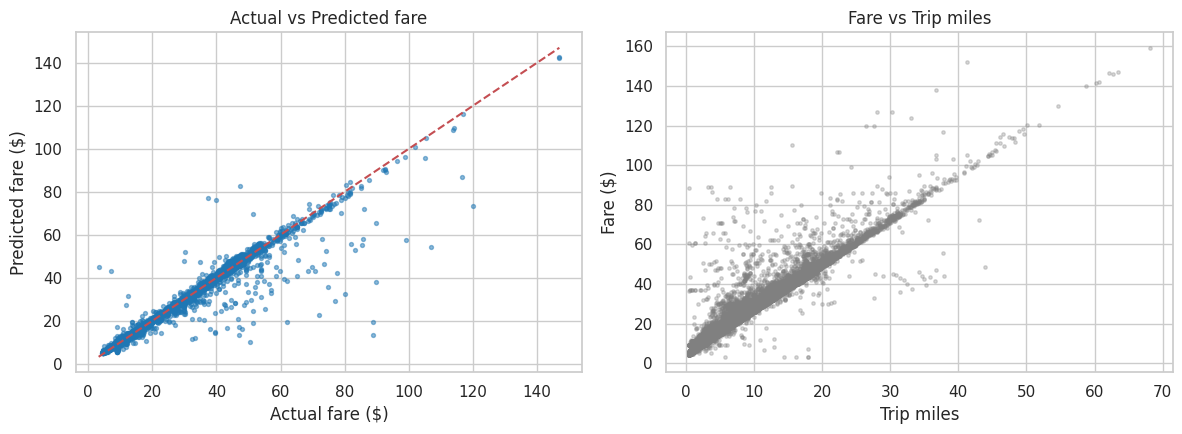

In [5]:
# 4. Evaluate
mse  = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = metrics.r2_score(y_test, y_pred)
n_, p_ = X_test.shape
adj_r2 = 1 - (1 - r2) * (n_ - 1) / (n_ - p_ - 1)

print(f"MSE         : {mse:.4f}")
print(f"RMSE        : {rmse:.4f}  (average error in $)")
print(f"R2 score    : {r2:.4f}")
print(f"Adjusted R2 : {adj_r2:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(y_test, y_pred, s=8, alpha=0.5, color="tab:blue")
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, "r--")
ax[0].set(title="Actual vs Predicted fare", xlabel="Actual fare ($)", ylabel="Predicted fare ($)")

ax[1].scatter(taxi["trip_miles"], taxi["fare"], s=6, alpha=0.3, color="gray")
ax[1].set(title="Fare vs Trip miles", xlabel="Trip miles", ylabel="Fare ($)")
plt.tight_layout(); plt.show()

In [6]:
# 5. Predict a new ride: 6 miles, 22 minutes, during rush hour
new_ride = pd.DataFrame([[6.0, 22 * 60, 1]], columns=features)
print(f"Predicted fare for the new ride: ${model.predict(new_ride)[0]:.2f}")

Predicted fare for the new ride: $19.09


## Exercise 2 – Predict body weight from height, age and gender
Dependent variable: **Weight**; independent variables: **Height, Age, Gender** (Gender is categorical → encoded as a 0/1 dummy variable).

> **Dataset – Gym Members Exercise Dataset (Kaggle: `valakhorasani/gym-members-exercise-dataset`).**
> Link: <https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset>
> **Records:** 973 gym members · **Features:** `Height` (m), `Age`, `Gender` · **Target:** `Weight` (kg).
> **Preprocessing:** kept the four relevant columns and renamed `Weight (kg)` / `Height (m)`; no nulls; Gender one-hot encoded (`Gender_Male`); 80/20 train-test split.
> **Why it fits:** it is a real table with exactly the variables the exercise names (weight, height, age, gender), and it is large enough for a proper train/test evaluation.

In [7]:
gym = load_data("gym_members_exercise_tracking.csv",
                "https://raw.githubusercontent.com/Mohammadprsd/GYM-members-exercise-tracking/main/gym_members_exercise_tracking.csv")
body = gym.rename(columns={"Weight (kg)": "Weight", "Height (m)": "Height"})[["Weight", "Height", "Age", "Gender"]]
print(body.shape, "| nulls:", body.isnull().sum().sum())
body.head()

(973, 4) | nulls: 0


,Weight,Height,Age,Gender
0,88.3,1.71,56,Male
1,74.9,1.53,46,Female
2,68.1,1.66,32,Female
3,53.2,1.70,25,Male
4,46.1,1.79,38,Male


In [8]:
# Encode Gender (Male = 1, Female = 0), separate X / y and split
X = pd.get_dummies(body[["Height", "Age", "Gender"]], columns=["Gender"], drop_first=True).astype(float)
y = body["Weight"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_train, y_train)

print("Feature columns:", list(X.columns))
print(f"\nIntercept (b0): {lr.intercept_:.3f}")
for name, c in zip(X.columns, lr.coef_):
    print(f"  {name:<12}: {c:8.3f}")

print("\nEquation:  Weight = {:.2f} + {:.2f}*Height + {:.3f}*Age + {:.2f}*Gender_Male".format(lr.intercept_, *lr.coef_))

Feature columns: ['Height', 'Age', 'Gender_Male']

Intercept (b0): 51.179
  Height      :    8.642
  Age         :   -0.122
  Gender_Male :   22.933

Equation:  Weight = 51.18 + 8.64*Height + -0.122*Age + 22.93*Gender_Male


Test R2 = 0.347 | Adjusted R2 = 0.336 | RMSE = 17.45 kg
5-fold CV R2 = 0.337 (+/- 0.012)


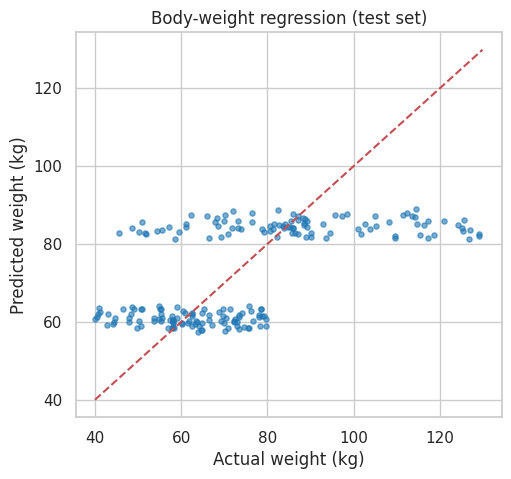


Predicted weight for a 1.75 m, 30-year-old male: 85.6 kg


In [9]:
# Evaluation on the held-out test set + 5-fold cross-validation
from sklearn.model_selection import cross_val_score

pred_test = lr.predict(X_test)
r2  = metrics.r2_score(y_test, pred_test)
adj = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X.shape[1] - 1)
print(f"Test R2 = {r2:.3f} | Adjusted R2 = {adj:.3f} | RMSE = {np.sqrt(metrics.mean_squared_error(y_test, pred_test)):.2f} kg")

cv_r2 = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print(f"5-fold CV R2 = {cv_r2.mean():.3f} (+/- {cv_r2.std():.3f})")

plt.figure(figsize=(5.5, 5))
plt.scatter(y_test, pred_test, s=14, alpha=0.6, color="tab:blue")
lims = [y.min(), y.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual weight (kg)"); plt.ylabel("Predicted weight (kg)")
plt.title("Body-weight regression (test set)"); plt.show()

# Predict a new person: 1.75 m, 30 years, male
new_person = pd.DataFrame([[1.75, 30, 1.0]], columns=X.columns)
print(f"\nPredicted weight for a 1.75 m, 30-year-old male: {lr.predict(new_person)[0]:.1f} kg")